In [1]:
import os
import pandas as pd
import numpy as np
from sub_tsmd import load_validation, load_test, plot_motif_sets

In [2]:
path = '../'
benchmark_path = f'{path}/noisy-data/'
seed = 42

In [3]:
signal_to_noise_ratios = [0.1, 0.2, 0.3, 0.4, 0.5]
signal_to_noise_ratios

[0.1, 0.2, 0.3, 0.4, 0.5]

In [4]:
DATASETS = {
    'synthetic': [
        's1'
    ]
} 

In [5]:
def add_noise(X, snr):
    return X + np.random.normal(loc=0, scale=snr * X.std(), size=X.shape)


metadata = []
for origin in DATASETS:
    metadata_origin = pd.read_csv(f'{path}/{origin}/metadata.csv', index_col='ds_name')
    
    for ds_name in DATASETS[origin]:
        
        # Load the data       
        metadata_ds = metadata_origin.loc[ds_name]
        X_train, y_train = load_validation(f'{path}/{origin}/{ds_name}')
        X_test, y_test = load_test(f'{path}/{origin}/{ds_name}')

        for signal_to_noise_ratio in signal_to_noise_ratios:
            
            name = f'{ds_name}@{origin}#{signal_to_noise_ratio}-snr'.lower()
            print(name)
                        
            # Generate the noisy train data
            np.random.seed(seed)
            X_train_noisy = [add_noise(X_train[i], signal_to_noise_ratio) for i in range(len(X_train))]
                        
            # Generate the noisy test data
            np.random.seed(seed)
            X_test_noisy = [add_noise(X_test[i], signal_to_noise_ratio) for i in range(len(X_test))]
            
            # Save the noisy data
            path_to_benchmark_dataset = f'{benchmark_path}/{name}'
            if not os.path.exists(path_to_benchmark_dataset):
                os.mkdir(path_to_benchmark_dataset) 
            benchmark_train = pd.DataFrame(data={'ts': X_train_noisy, 'gt': y_train})
            benchmark_train.to_pickle(os.path.join(path_to_benchmark_dataset, 'validation.pkl'))
            benchmark_test = pd.DataFrame(data={'ts': X_test_noisy, 'gt': y_test})
            benchmark_test.to_pickle(os.path.join(path_to_benchmark_dataset, 'test.pkl'))
            
            # Set the meta data  
            metadata_ds = metadata_origin.loc[ds_name].copy()
            keys = list(metadata_ds.index)
            values = list(metadata_ds.values)
            keys.insert(0, 'base_ds_name')  # To more easily find the hyperparameters
            values.insert(0, ds_name)
            metadata_ds = pd.Series(values, index=keys, name=name)
            metadata.append(metadata_ds)
            
metadata = pd.concat(metadata, axis=1).T
metadata.index.name = 'ds_name'

base@synthetic#0.1-snr
base@synthetic#0.2-snr
base@synthetic#0.3-snr
base@synthetic#0.4-snr
base@synthetic#0.5-snr


In [6]:
metadata = metadata.astype({'l_min': int, 'l_max': int, 'D': int, 'g_max': int, 'r': float, 'n_avg_train': float, 'n_avg_test': float, 'n_avg': float})
metadata.to_csv(os.path.join(benchmark_path, 'metadata.csv'))
metadata

,base_ds_name,l_min,l_max,D,g_max,r,n_avg_train,n_avg_test,n_avg
ds_name,,,,,,,,,
base@synthetic#0.1-snr,base,50,50,6,5,3.6272,1190.34,1154.435,1161.616
base@synthetic#0.2-snr,base,50,50,6,5,3.6272,1190.34,1154.435,1161.616
base@synthetic#0.3-snr,base,50,50,6,5,3.6272,1190.34,1154.435,1161.616
base@synthetic#0.4-snr,base,50,50,6,5,3.6272,1190.34,1154.435,1161.616
base@synthetic#0.5-snr,base,50,50,6,5,3.6272,1190.34,1154.435,1161.616


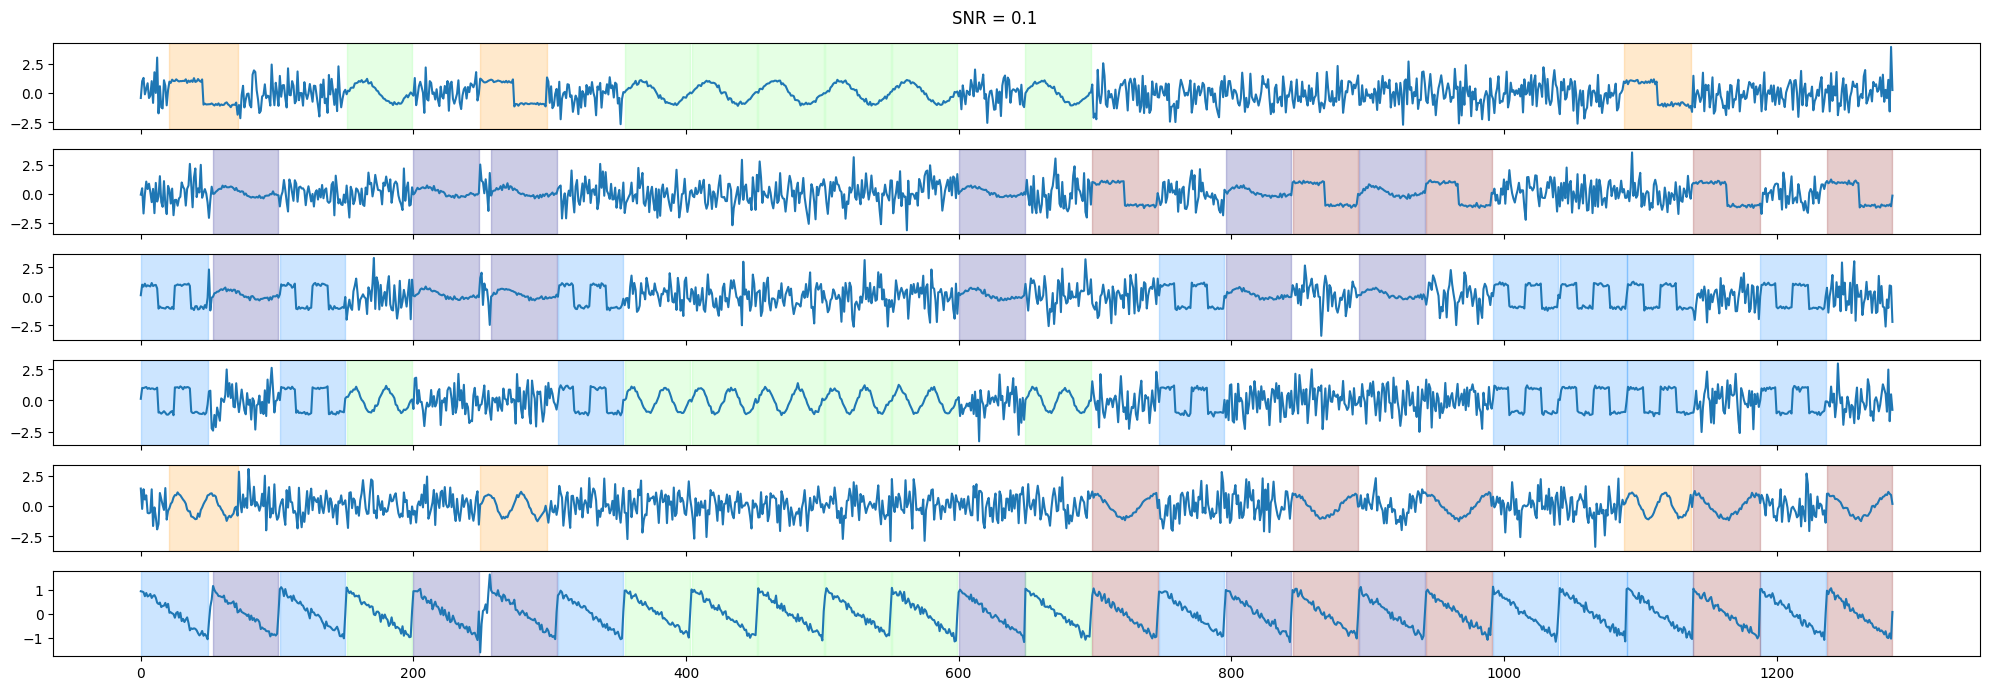

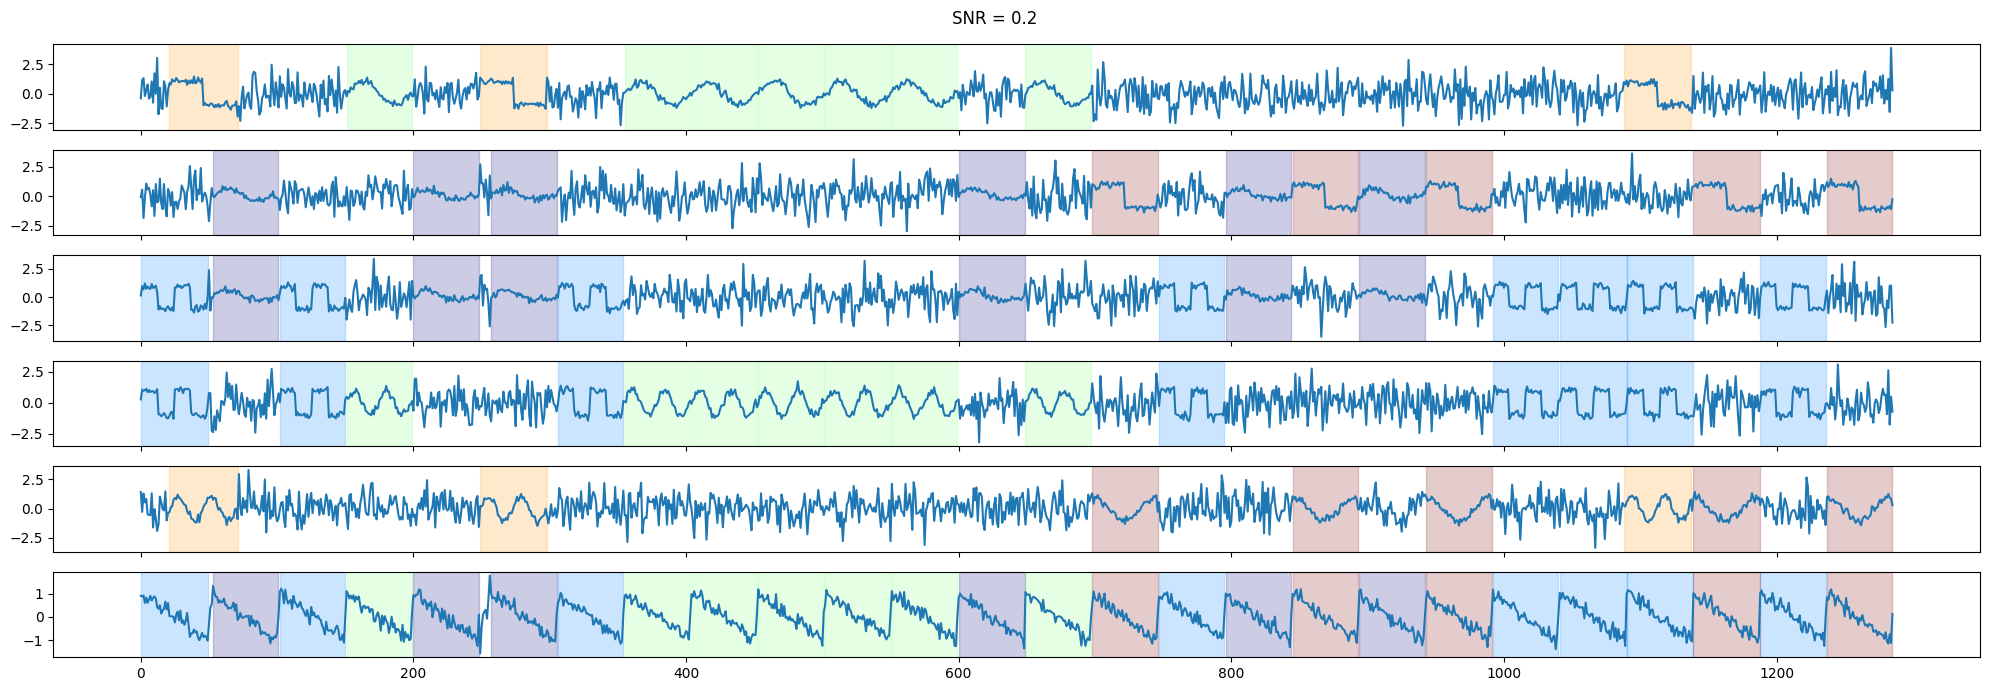

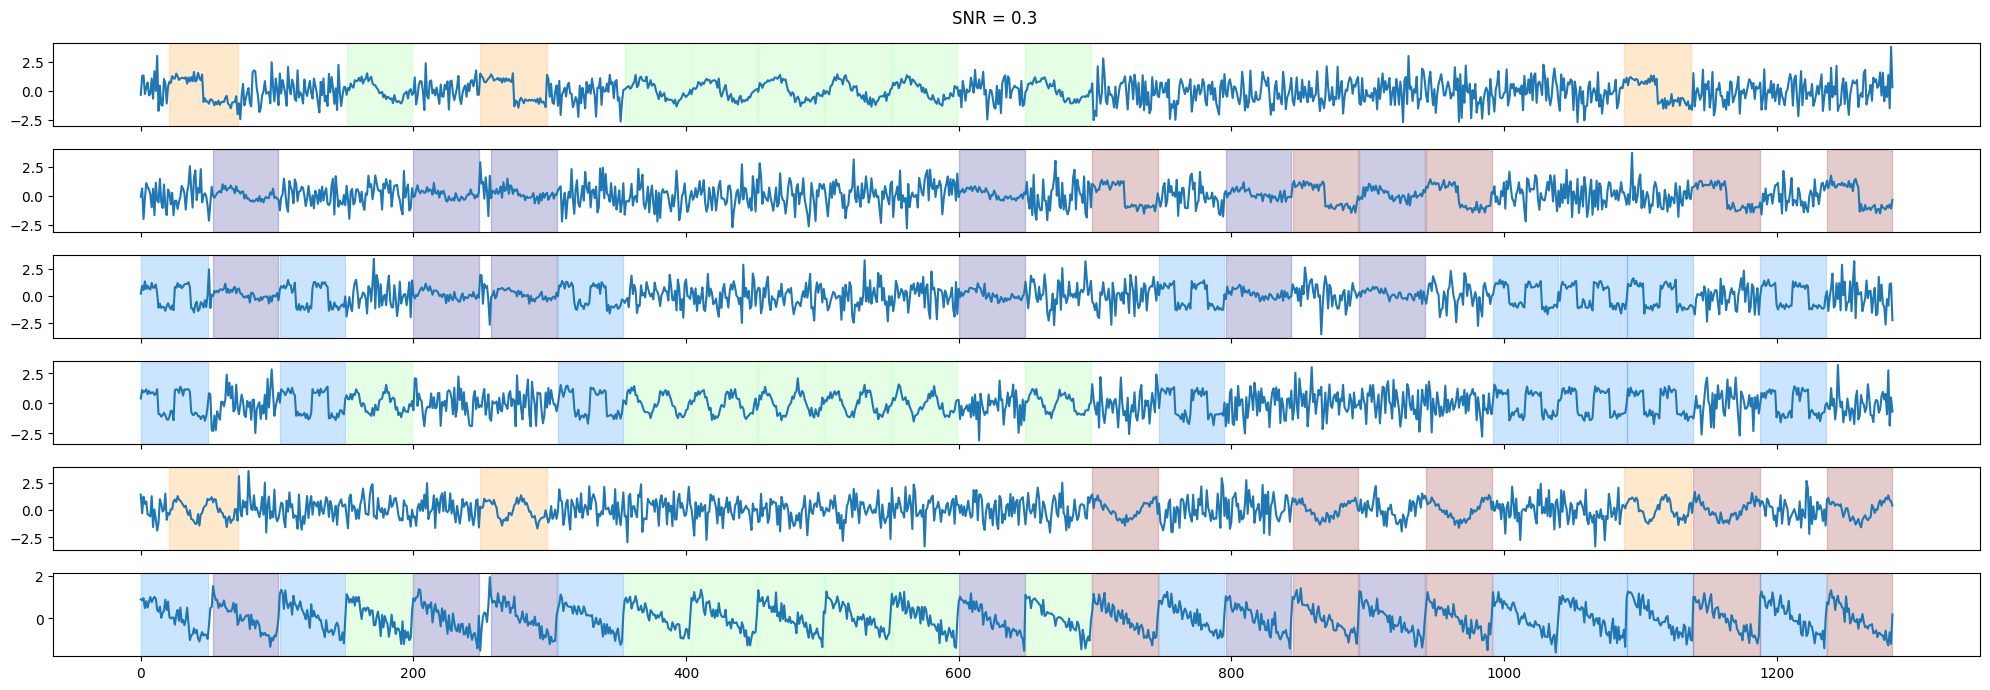

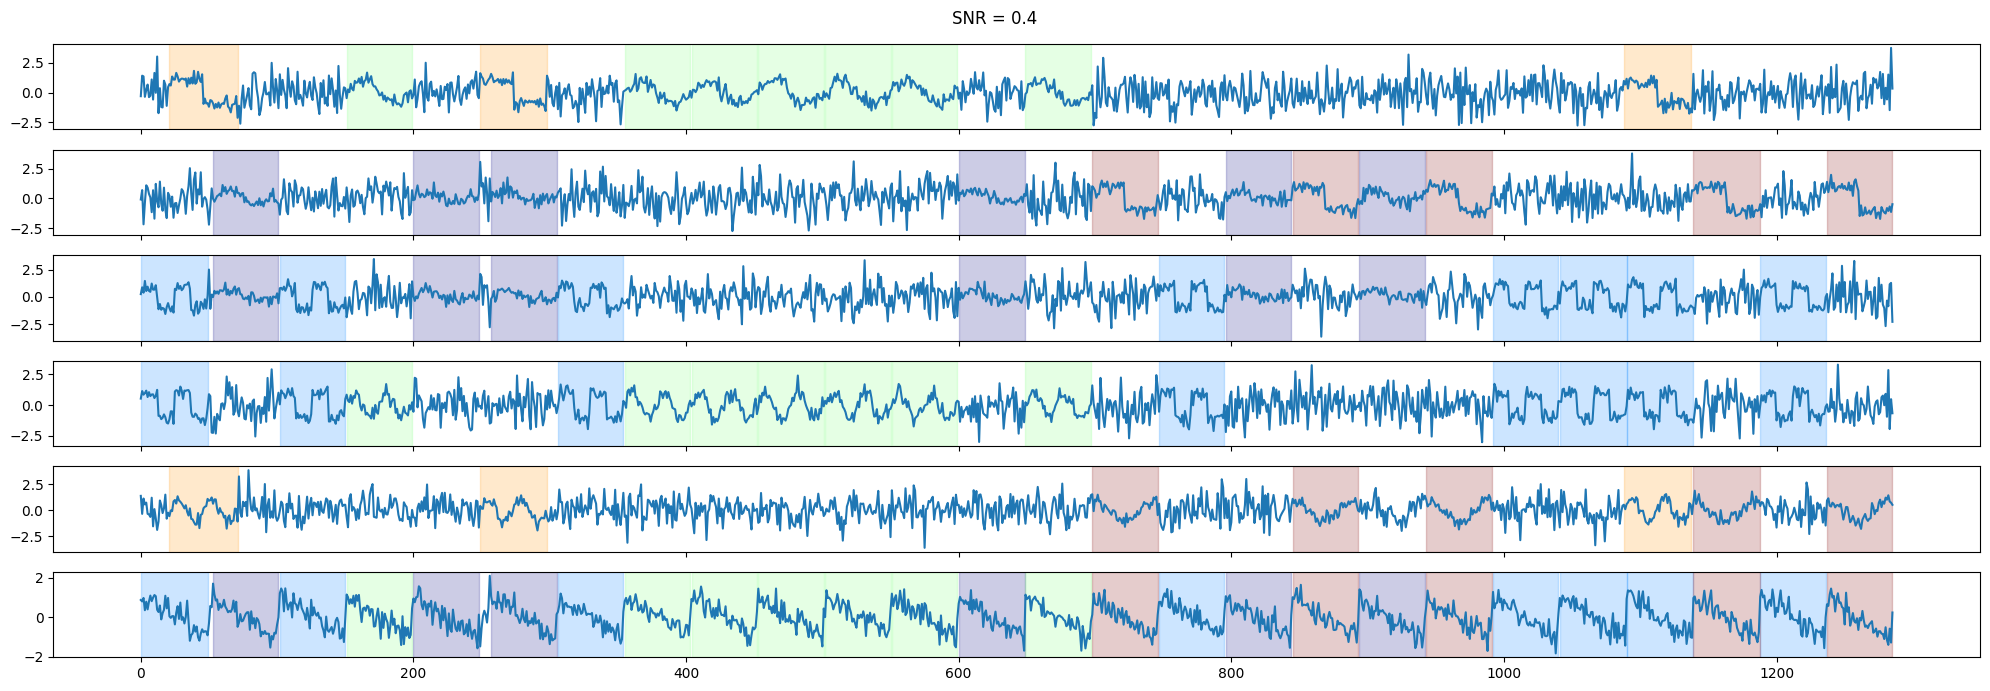

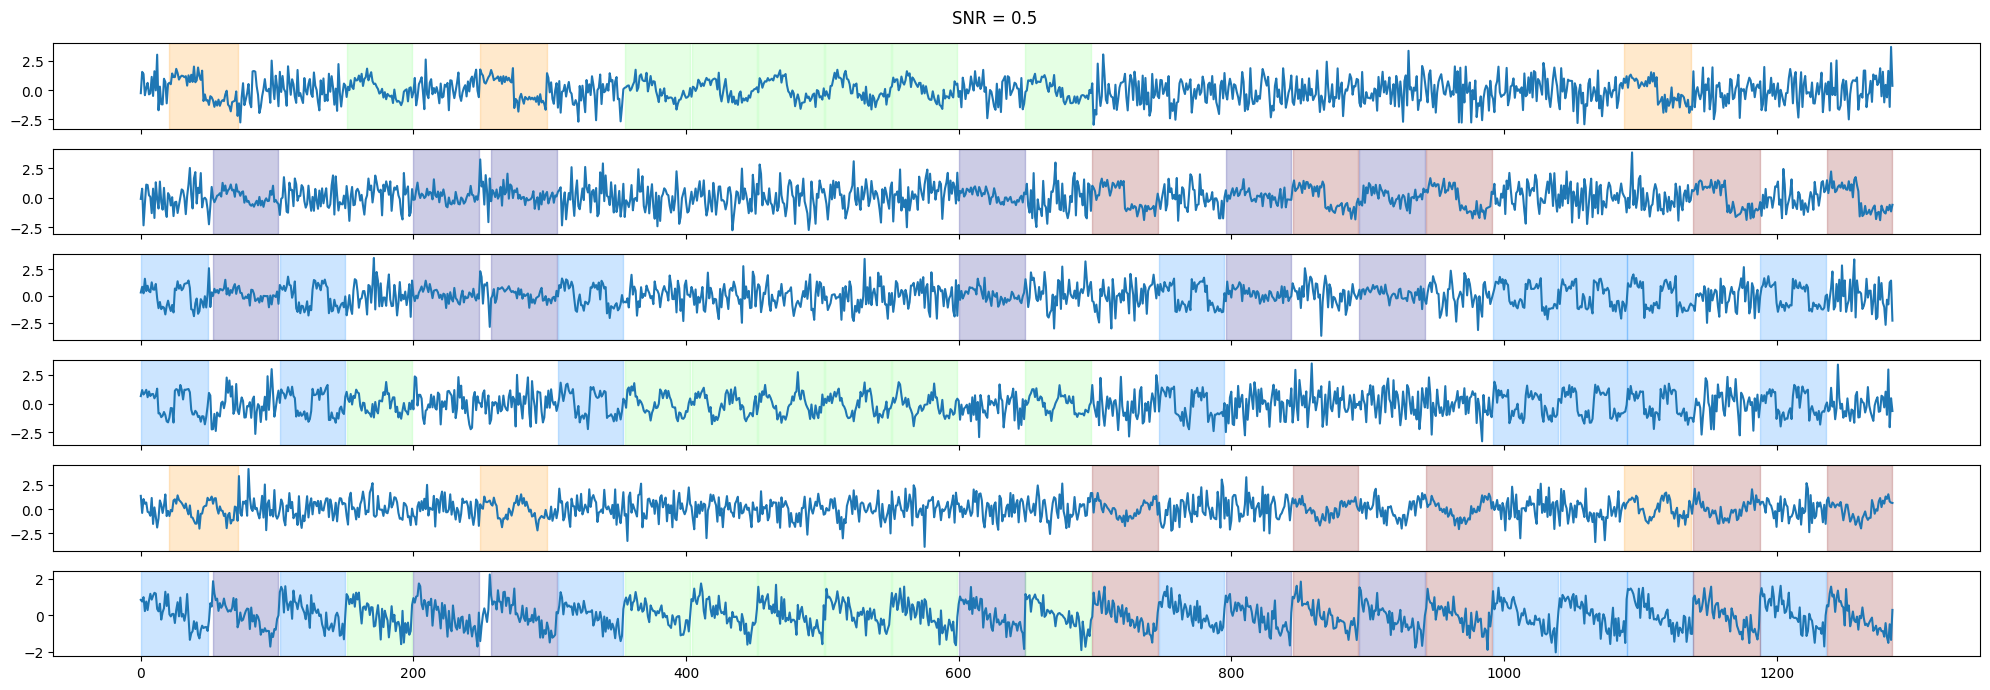

In [7]:
for signal_to_noise_ratio in signal_to_noise_ratios:
    Xs, ys = load_validation(f"s1@synthetic#{signal_to_noise_ratio}-snr")
    fig = plot_motif_sets(Xs[0], ys[0])
    fig.suptitle(f'SNR = {signal_to_noise_ratio}')
    fig.tight_layout()